# Solution Error vs Nonlinearity Error

Load a directory of FOM or ROM training runs, compare each final learned neural nonlinearity against the true Allen-Cahn nonlinearity, and rank runs by nonlinearity L2 error.

In [59]:
### ADJUSTED: Configure grouped FOM/ROM run analysis for solution-loss vs nonlinearity-error comparisons.
include(joinpath(@__DIR__, "..", "..", "src", "Visualizations", "optimization_visualizations.jl"))

const FOM = :FOM
const ROM = :ROM

MODEL_TYPE = FOM

# ROM hyperparameter optimization: ROM_M_R_HPO
# FOM hyperparameter optimization: FOM_HPO

GROUP_DIR = joinpath(@__DIR__, "..", "Data", "FOM_HPO")

U_MIN = -1.0
U_MAX = 1.0
L2_POINTS = 1000

1000

In [60]:
function model_file(model_type)
    model_type == FOM && return "run_params.jls"
    model_type == ROM && return "rom_data.jls"
    error("MODEL_TYPE must be FOM or ROM")
end

function run_directories(group_dir::AbstractString, model_type)
    expected_file = model_file(model_type)
    dirs = sort(filter(isdir, readdir(group_dir; join=true)))
    runs = filter(d -> isfile(joinpath(d, "metadata.txt")) &&
                       isfile(joinpath(d, "parameter_history.jls")) &&
                       isfile(joinpath(d, expected_file)), dirs)
    isempty(runs) && error("No $(model_type) run directories found in $(group_dir)")
    return runs
end

function metadata_float(run_dir::AbstractString, key::AbstractString)
    prefix = key * " ="
    for line in eachline(joinpath(run_dir, "metadata.txt"))
        startswith(line, prefix) && return parse(Float64, strip(split(line, "="; limit=2)[2]))
    end
    error("Missing $(key) in $(joinpath(run_dir, "metadata.txt"))")
end

final_loss_from_run(run_dir::AbstractString) = metadata_float(run_dir, "final_loss")

final_loss_from_run (generic function with 1 method)

In [61]:
function load_nn_params(run_dir::AbstractString, model_type)
    θ = final_theta(run_dir)
    if model_type == ROM
        data = load_rom_data(run_dir)
    elseif model_type == FOM
        data = load_fom_run_params(run_dir)
    else
        error("MODEL_TYPE must be FOM or ROM")
    end
    return (; θ, h=data.h, seed=data.seed, k=saved_k(data))
end

function nonlinearity_l2_error(nn_params; u_min=U_MIN, u_max=U_MAX, n=L2_POINTS)
    u = collect(LinRange(u_min, u_max, n))
    learned = learned_function_values(u, nn_params.θ, nn_params.h, nn_params.seed)
    truth = true_function_values(u, nn_params.k)
    errs2 = (learned .- truth) .^ 2
    du = (u_max - u_min) / (n - 1)
    return sqrt(du * (0.5first(errs2) + sum(errs2[2:end-1]) + 0.5last(errs2)))
end

function load_run_result(run_dir::AbstractString, model_type)
    nn_params = load_nn_params(run_dir, model_type)
    final_loss = final_loss_from_run(run_dir)
    f_l2_error = nonlinearity_l2_error(nn_params)
    return (; run_name=basename(run_dir), run_dir, final_loss, f_l2_error, nn_params)
end

load_run_result (generic function with 1 method)

In [62]:
function load_group_results(group_dir::AbstractString, model_type)
    runs = run_directories(group_dir, model_type)
    results = [load_run_result(run_dir, model_type) for run_dir in runs]
    return sort(results; by=row -> row.f_l2_error)
end

function loss_error_pairs(results)
    return [(row.final_loss, row.f_l2_error) for row in results]
end

function print_l2_table(results)
    @printf("%-72s %16s %16s\n", "run_name", "final_loss", "f_l2_error")
    @printf("%s\n", repeat("-", 108))
    for row in results
        @printf("%-72s %16.8e %16.8e\n", row.run_name, row.final_loss, row.f_l2_error)
    end
    return nothing
end

function plot_loss_vs_nonlinearity_error(results)
    losses = getproperty.(results, :final_loss)
    errors = getproperty.(results, :f_l2_error)
    labels = string.(eachindex(results))
    scatter(losses, errors;
        xlabel="trajectory final loss",
        ylabel="f(u) L2 error",
        label="runs",
        series_annotations=labels,
        xscale=:log10,
        yscale=:log10,
        title="Trajectory loss vs learned nonlinearity error")
end

function plot_loss_vs_nonlinearity_error(results)
    losses = getproperty.(results, :final_loss)
    errors = getproperty.(results, :f_l2_error)
    colors = collect(eachindex(results))

    scatter(losses, errors;
        zcolor=colors,
        markerstrokewidth=0,
        colorbar=true,
        colorbar_title="rank",
        xlabel="trajectory final loss",
        ylabel="f(u) L2 error",
        label=false,
        xscale=:log10,
        yscale=:log10,
        title="Trajectory loss vs learned nonlinearity error")
end

function plot_nn_result(results, index::Integer; u_min=U_MIN, u_max=U_MAX, n=500)
    row = results[index]
    u = collect(LinRange(u_min, u_max, n))
    truth = true_function_values(u, row.nn_params.k)
    learned = learned_function_values(u, row.nn_params.θ, row.nn_params.h, row.nn_params.seed)
    plot(u, truth;
        label="true -k(u^3-u)",
        xlabel="u",
        ylabel="f(u)",
        linewidth=3,
        title="$(index): $(row.run_name)")
    plot!(u, learned; label="learned NN", linewidth=2, linestyle=:dash)
end

plot_nn_result (generic function with 1 method)

In [63]:
results_table = load_group_results(GROUP_DIR, MODEL_TYPE)
pairs = loss_error_pairs(results_table)

print_l2_table(results_table)

run_name                                                                       final_loss       f_l2_error
------------------------------------------------------------------------------------------------------------
FOM_true_hpo_mooncake_90_82_083_long60m_w_0p05_1p0_2p0__obs_10_25_50__eta_0.003_0.001_0.0003__b_1_1_1   1.33495875e-07   1.46093507e-03
FOM_true_hpo_mooncake_90_85_086_long60m_w_0p1_1p0_2p0__obs_10_25_50__eta_0.003_0.001_0.0003__b_1_1_1   1.35111479e-07   1.46764862e-03
FOM_true_hpo_mooncake_90_88_089_long60m_w_0p05_0p5_2p0__obs_10_25_50__eta_0.003_0.001_0.0003__b_1_1_1   1.33361322e-07   1.46959099e-03
FOM_true_hpo_mooncake_90_45_046_medium30m_w_0p05_1p0_2p0__obs_5_10_25__eta_0.003_0.001_0.0003__b_1_1_1   1.34236024e-07   1.71459672e-03
FOM_true_hpo_mooncake_90_57_058_medium30m_w_0p05_0p5_2p0__obs_5_10_25__eta_0.003_0.001_0.0003__b_1_1_1   1.33500879e-07   1.79688755e-03
FOM_true_hpo_mooncake_90_51_052_medium30m_w_0p1_1p0_2p0__obs_5_10_25__eta_0.003_0.001_0.0003__b_1_1_1  

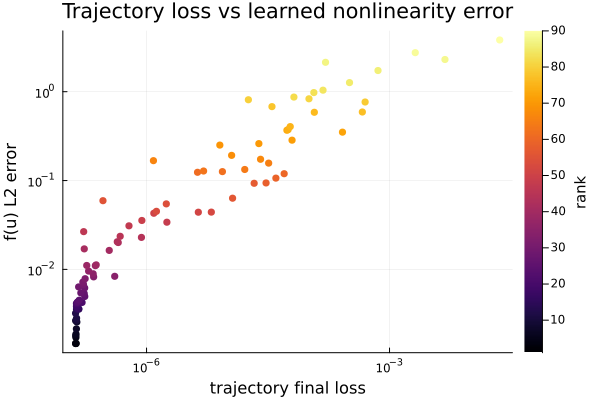

In [64]:
plot_loss_vs_nonlinearity_error(results_table)

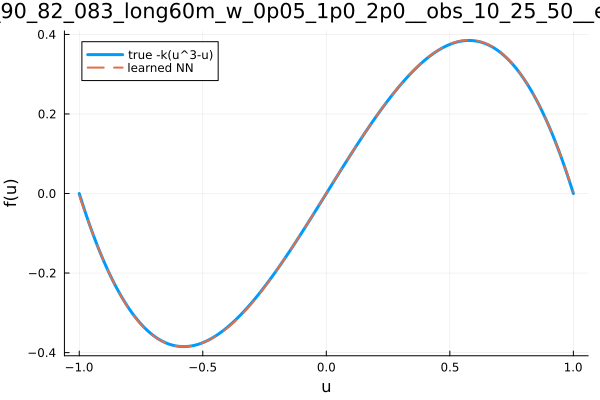

In [67]:
plot_nn_result(results_table, 1)